In [2]:
# 数据处理
import pandas as pd
import numpy as np
# 可视化
import seaborn as sns
import matplotlib.pyplot as plt
# 聚类
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
# 多重共线性、统计检验
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
# 降维PCA
from sklearn.decomposition import PCA
# 线性回归
from sklearn.linear_model import LinearRegression
# 数据集划分、模型评估
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
# 正态检验
import scipy.stats as stats
# 树模型
from sklearn.ensemble import RandomForestRegressor

# 解决中文显示
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False

In [31]:
# 读取数据
train_data = pd.read_csv("C:/Users/惠普/Desktop/Blueberry_Yield_Prediction/data/train.csv")
test_data = pd.read_csv("C:/Users/惠普/Desktop/Blueberry_Yield_Prediction/data/test.csv")

In [32]:
# 1. 查看数据维度
print('训练集维度:')
print(train_data.shape)
print('-'*50)
print('测试集维度:')
print(test_data.shape)

训练集维度:
(15289, 18)
--------------------------------------------------
测试集维度:
(10194, 17)


In [33]:
# 2. 查看数据信息
print('-'*50)
print('训练集信息:')
print(train_data.info())
print('测试集信息:')
print(test_data.info())

--------------------------------------------------
训练集信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15289 entries, 0 to 15288
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    15289 non-null  int64  
 1   clonesize             15289 non-null  float64
 2   honeybee              15289 non-null  float64
 3   bumbles               15289 non-null  float64
 4   andrena               15289 non-null  float64
 5   osmia                 15289 non-null  float64
 6   MaxOfUpperTRange      15289 non-null  float64
 7   MinOfUpperTRange      15289 non-null  float64
 8   AverageOfUpperTRange  15289 non-null  float64
 9   MaxOfLowerTRange      15289 non-null  float64
 10  MinOfLowerTRange      15289 non-null  float64
 11  AverageOfLowerTRange  15289 non-null  float64
 12  RainingDays           15289 non-null  float64
 13  AverageRainingDays    15289 non-null  float64
 14  fruitset    

常用检查缺失值;识别数据类型问题;掌握数据集规模;快速浏览全部特征;评估内存占用

In [6]:
# 3. 缺失值检测
print('训练集缺失情况:')
print(train_data.isna().sum())
print('-'*50)
print('测试集缺失情况:')
print(test_data.isna().sum())

训练集缺失情况:
id                      0
clonesize               0
honeybee                0
bumbles                 0
andrena                 0
osmia                   0
MaxOfUpperTRange        0
MinOfUpperTRange        0
AverageOfUpperTRange    0
MaxOfLowerTRange        0
MinOfLowerTRange        0
AverageOfLowerTRange    0
RainingDays             0
AverageRainingDays      0
fruitset                0
fruitmass               0
seeds                   0
yield                   0
dtype: int64
--------------------------------------------------
测试集缺失情况:
id                      0
clonesize               0
honeybee                0
bumbles                 0
andrena                 0
osmia                   0
MaxOfUpperTRange        0
MinOfUpperTRange        0
AverageOfUpperTRange    0
MaxOfLowerTRange        0
MinOfLowerTRange        0
AverageOfLowerTRange    0
RainingDays             0
AverageRainingDays      0
fruitset                0
fruitmass               0
seeds                   0
dtype: i

用于精准量化缺失检测，精确统计每列缺失数量、做自动化清洗、计算缺失占比、绘图分析，是正式缺失处理的标准代码


In [7]:
# 4. 重复值检测
print('训练集重复行数：', train_data.duplicated().sum())
print('测试集重复行数：', test_data.duplicated().sum())

训练集重复行数： 0
测试集重复行数： 0


In [8]:
# 5. 数据预处理：删除无意义id列
train_data.drop(['id'], axis=1, inplace=True)
test_data.drop(['id'], axis=1, inplace=True)

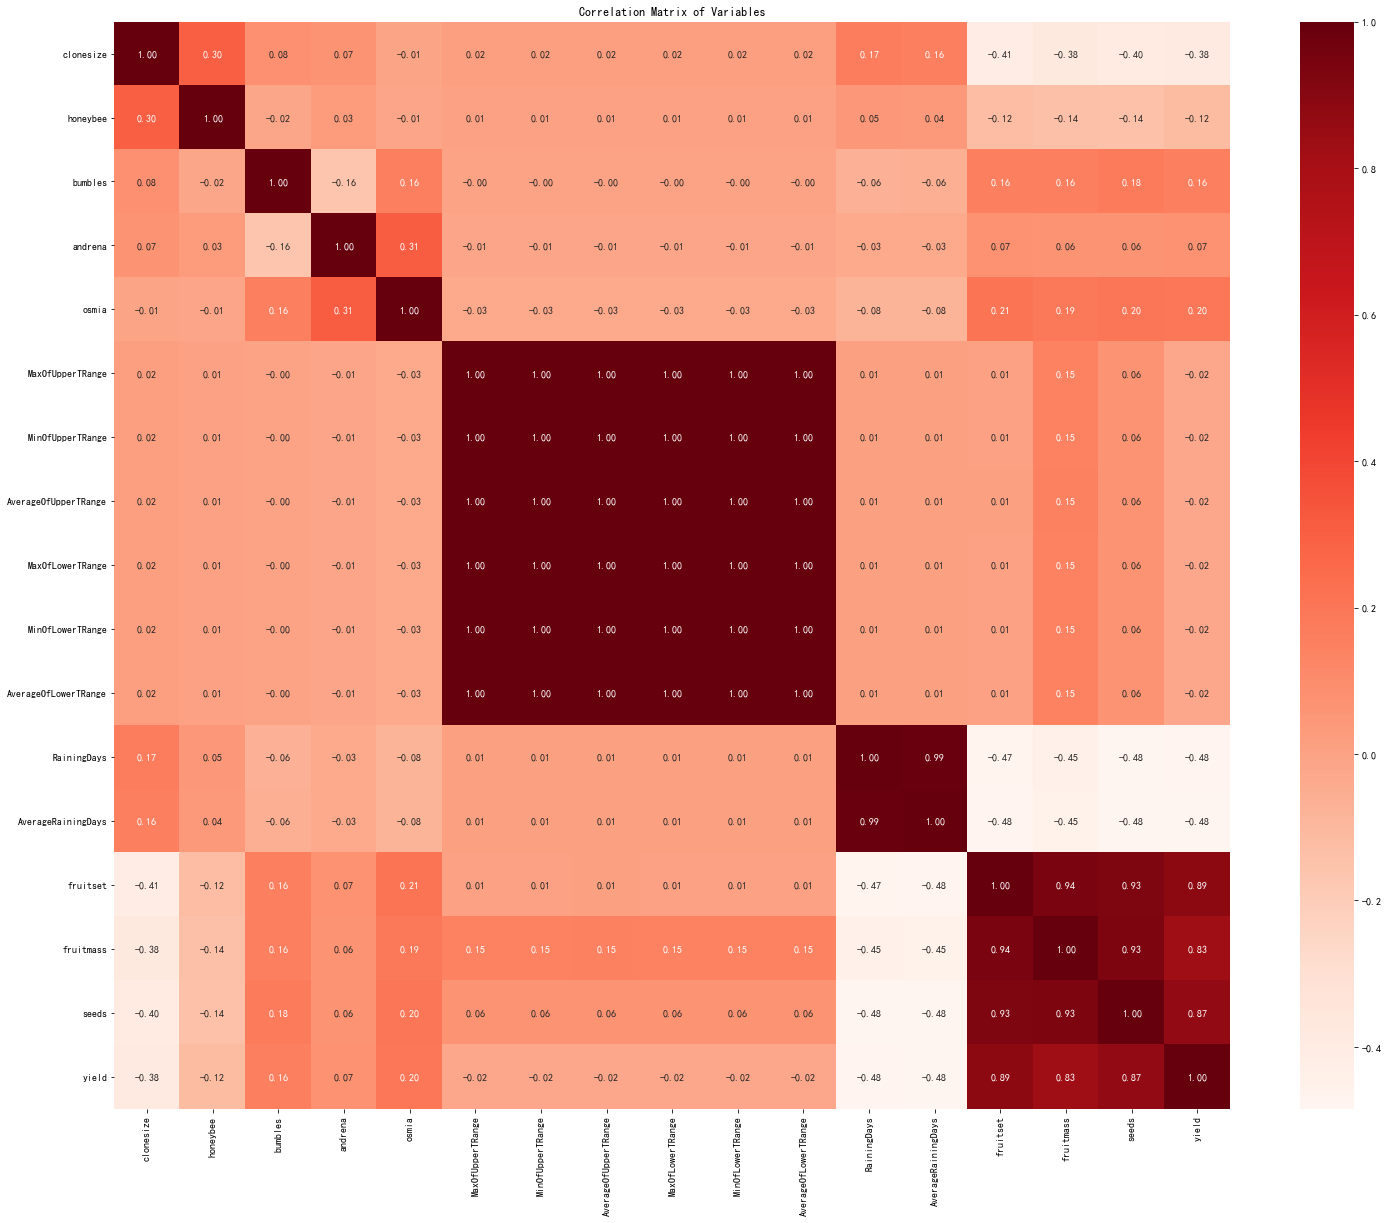

In [19]:
# 计算相关系数矩阵
correlation_matrix = train_data.corr()

# 绘制相关性热力图
plt.figure(figsize=(25, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='Reds', fmt=".2f")
plt.title("Correlation Matrix of Variables")
plt.show()

发现变量之间存在高度共线性。可能导致过拟合，后续考虑PCA降维


In [20]:
# 复制训练集用于聚类
x_cluster = train_data.copy()
# 标准化
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_cluster)

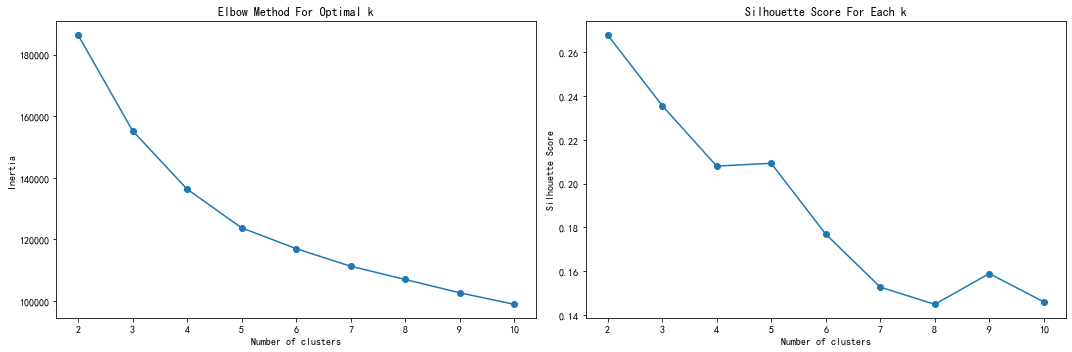

In [24]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=10).fit(x_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(x_scaled, kmeans.labels_))

# 双图绘制
plt.figure(figsize=(15, 5))
# 左图：肘部法则
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
# 右图：轮廓系数
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score For Each k')
plt.tight_layout()
plt.show()

通过对比发现，k=4时聚类效果最佳。将模型分为四类，两组高产群，一组中产，一组低产


In [25]:
# 构建4聚类模型
kmeans_final = KMeans(n_clusters=4, random_state=15)
kmeans_final.fit(x_scaled)
cluster_labels = kmeans_final.labels_

# 聚类标签合并至原始数据
train_data_clustered = train_data.copy()
train_data_clustered['Cluster'] = cluster_labels

# 各聚类均值统计
cluster_summary = train_data_clustered.groupby('Cluster').mean()
print(cluster_summary)

         clonesize  honeybee   bumbles   andrena     osmia  MaxOfUpperTRange  \
Cluster                                                                        
0        17.644277  0.351528  0.295053  0.498074  0.612222         89.645498   
1        22.004267  0.429347  0.278173  0.488991  0.580457         72.474424   
2        22.270551  0.437982  0.275738  0.484489  0.560774         90.491035   
3        17.328080  0.346109  0.296424  0.498191  0.612562         74.767492   

         MinOfUpperTRange  AverageOfUpperTRange  MaxOfLowerTRange  \
Cluster                                                             
0               54.206513             74.912739         64.628448   
1               43.797838             60.539772         52.218265   
2               54.710668             75.607715         65.237723   
3               45.189268             62.475436         53.893253   

         MinOfLowerTRange  AverageOfLowerTRange  RainingDays  \
Cluster                                 

In [26]:
# 拆分特征与标签
X = train_data.drop(['yield'], axis=1)
# 添加常数项
X_vif = sm.add_constant(X)

# 计算VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

                 feature           VIF
0                  const    452.702544
1              clonesize      1.376754
2               honeybee      1.120483
3                bumbles      1.151751
4                andrena      1.186737
5                  osmia      1.200157
6       MaxOfUpperTRange   3414.130675
7       MinOfUpperTRange    559.970976
8   AverageOfUpperTRange  30443.904985
9       MaxOfLowerTRange   1105.083282
10      MinOfLowerTRange  24965.147210
11  AverageOfLowerTRange  23062.819227
12           RainingDays     55.514009
13    AverageRainingDays     56.054862
14              fruitset     11.967936
15             fruitmass     12.726585
16                 seeds      9.797380


In [27]:
# 标准化特征
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

# PCA分解
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 单主成分方差贡献率
explained_variance = pca.explained_variance_ratio_
print("各主成分方差贡献率：\n", explained_variance)

# 累积方差贡献率
cumulative_variance = np.cumsum(explained_variance)
# 筛选累计95%方差的主成分
n_components = np.where(cumulative_variance >= 0.95)[0][0] + 1
print(f'前{n_components}个主成分累计方差贡献率达到95%')

# 截取前N个主成分
X_pca_reduced = X_pca[:, :n_components]
y = train_data['yield']

各主成分方差贡献率：
 [3.77418076e-01 2.44286924e-01 8.51790842e-02 8.34677450e-02
 7.26665536e-02 5.73632445e-02 3.90780709e-02 3.21118075e-02
 4.43381609e-03 3.24392256e-03 5.63408861e-04 1.27603202e-04
 4.17748878e-05 1.46630704e-05 1.89651779e-06 1.40930816e-06]
前7个主成分累计方差贡献率达到95%


In [28]:
# 划分训练、测试集
X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca_reduced, y, test_size=0.3, random_state=15
)

# 线性回归模型
regression_model = LinearRegression()
regression_model.fit(X_train_pca, y_train)

# 预测
y_pred = regression_model.predict(X_test_pca)

# 模型评估指标
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")


Mean Squared Error (MSE): 393493.04628487345
R-squared (R2): 0.7870589957164607


得到（R2）准备做残差分析，验证线性回归模型是否适用


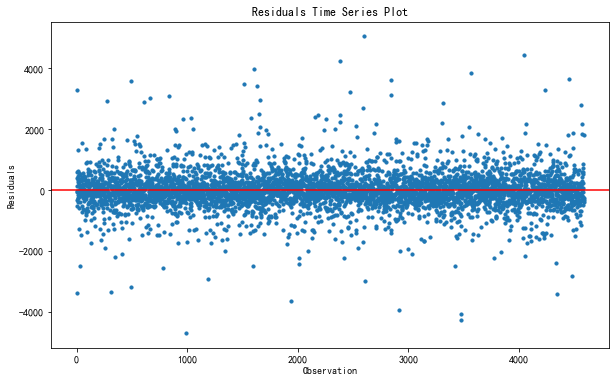

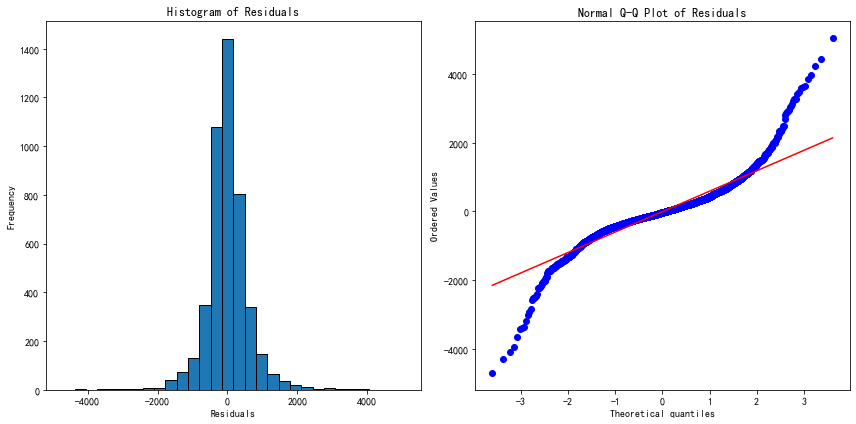

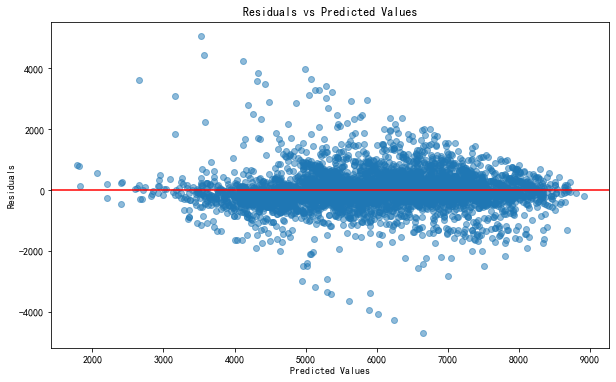

In [29]:
# 计算残差
residuals = y_test - y_pred

# 1. 残差时序图
plt.figure(figsize=(10, 6))
plt.scatter(range(len(residuals)), residuals, marker='o', s=10)
plt.axhline(y=0, color='r', linestyle='-')
plt.title("Residuals Time Series Plot")
plt.xlabel("Observation")
plt.ylabel("Residuals")
plt.show()

# 2. 残差直方图 + Q-Q正态检验图
plt.figure(figsize=(12, 6))
# 直方图
plt.subplot(1, 2, 1)
plt.hist(residuals, bins=30, edgecolor='black')
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
# Q-Q图
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

# 3. 残差vs预测值（同方差检验）
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='-')
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

In [30]:
# 测试集标准化+PCA降维
X_test_scaled = scaler_pca.transform(test_data)
X_test_pca = pca.transform(X_test_scaled)
X_test_pca_reduced = X_test_pca[:, :n_components]

# 预测
test_predictions = regression_model.predict(X_test_pca_reduced)

# 预测结果存入测试集副本
test_data_with_predictions = test_data.copy()
test_data_with_predictions['predicted_yield'] = test_predictions
print(test_data_with_predictions.head())

   clonesize  honeybee  bumbles  andrena  osmia  MaxOfUpperTRange  \
0       25.0      0.25     0.25     0.25   0.25              86.0   
1       12.5      0.25     0.25     0.75   0.63              94.6   
2       12.5      0.25     0.25     0.63   0.63              86.0   
3       25.0      0.50     0.38     0.38   0.63              86.0   
4       37.5      0.75     0.25     0.25   0.25              94.6   

   MinOfUpperTRange  AverageOfUpperTRange  MaxOfLowerTRange  MinOfLowerTRange  \
0              52.0                  71.9              62.0              30.0   
1              57.2                  79.0              68.2              33.0   
2              52.0                  71.9              62.0              30.0   
3              52.0                  71.9              62.0              30.0   
4              57.2                  79.0              68.2              33.0   

   AverageOfLowerTRange  RainingDays  AverageRainingDays  fruitset  fruitmass  \
0                